# MyPortfolioManagement - Complete Tutorial

This notebook demonstrates all major functions in the myPortfolioManagement library.

**Author:** Ferhat  
**Date:** December 2024

## Table of Contents
1. [Setup & Configuration](#setup)
2. [Data Fetching](#data-fetching)
3. [Returns Calculation](#returns-calculation)
4. [Utility Functions](#utility-functions)
5. [Portfolio Optimization](#portfolio-optimization)
6. [Performance Metrics](#performance-metrics)
7. [Low-Level Risk Metrics](#risk-metrics)
8. [Backtesting & Simulation](#backtesting)
9. [Bootstrapping](#bootstrapping)
10. [Clustering & Regime Detection](#clustering)
11. [Visualization](#plotting)
12. [Portfolio Selection](#portfolio-selection)
13. [Complete Workflow Example](#workflow)

## 1. Setup & Configuration <a id='setup'></a>

Import all necessary libraries and configure display settings.

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Fix for quantstats-lumi compatibility with newer Jupyter
import sys
if 'IPython' in sys.modules:
    from IPython import get_ipython
    ipython = get_ipython()
    if ipython is not None:
        # Monkey-patch to avoid the deprecated magic() call
        if not hasattr(ipython, 'magic'):
            ipython.magic = lambda x: None

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import quantstats_lumi as qs

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Matplotlib settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Setup complete!
Pandas version: 2.2.3
NumPy version: 1.26.4


In [3]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import quantstats_lumi as qs

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

# Matplotlib settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print("Setup complete!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Setup complete!
Pandas version: 2.2.3
NumPy version: 1.26.4


### Helper Function: Fix for Benchmark Returns

This fixes a quantstats DataFrame compatibility issue.

In [4]:
def get_benchmark_returns_fixed(ticker: str = '^GSPC', name: str = 'S&P500') -> pd.DataFrame:
    """
    Fixed version of get_benchmark_returns that handles quantstats DataFrame output.
    
    Args:
        ticker: Yahoo Finance ticker symbol (default: ^GSPC for S&P 500)
        name: Name for the return series
    
    Returns:
        DataFrame with benchmark returns
    """
    ret_data = qs.utils.download_returns(ticker)
    
    # Handle both Series and DataFrame returns
    if isinstance(ret_data, pd.DataFrame):
        ret = ret_data.squeeze()
    else:
        ret = ret_data
    
    ret.name = name
    return pd.DataFrame(ret)

print("Helper function loaded!")

Helper function loaded!


## 2. Data Fetching <a id='data-fetching'></a>

Fetch historical price data from Yahoo Finance for a diversified portfolio of ETFs.

In [5]:
from myPortfolioManagement.myData import (
    get_stock_prices,
    get_stock_info,
    get_option_exp_dates
)

# Define a diversified portfolio of ETFs
tickers = [
    'SPY',   # S&P 500
    'QQQ',   # Nasdaq 100
    'IWM',   # Russell 2000 (Small Cap)
    'EFA',   # International Developed
    'EEM',   # Emerging Markets
    'AGG',   # US Bonds
    'TIP',   # TIPS (Inflation Protected)
    'GLD',   # Gold
    'VNQ',   # Real Estate
    'DBC',   # Commodities
]

print(f"Fetching data for {len(tickers)} tickers...")
print(f"Tickers: {', '.join(tickers)}")

Fetching data for 10 tickers...
Tickers: SPY, QQQ, IWM, EFA, EEM, AGG, TIP, GLD, VNQ, DBC


In [13]:
# Fetch historical prices
prices = get_stock_prices(
    yahoo_tickers=tickers,
    start_date='2018-01-01',
    end_date='2025-12-21',
    freq='daily',
    wide_format=True
)

print(f"\nPrice data shape: {prices.shape}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print("\nFirst 5 rows:")
prices.head()

100%|██████████| 10/10 [00:00<?, ?it/s]


get_stock_prices took 2.656sec

Price data shape: (2004, 10)
Date range: 2018-01-02 00:00:00 to 2025-12-19 00:00:00

First 5 rows:


longname,Invesco DB Commodity Index Tracking Fund,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,,
2018-01-02,14.5853,150.6054,125.1500,237.2082,61.3691,86.9814,55.6033,39.9833,139.1314,88.6665
2018-01-03,14.6726,152.0687,124.8200,238.7086,61.1909,86.9894,55.8702,40.3664,139.2761,88.7523
2018-01-04,14.6552,152.3348,125.4600,239.7147,60.1368,86.9336,56.4825,40.5663,139.6468,88.7756
2018-01-05,14.6027,153.8647,125.3300,241.3121,60.1665,86.8778,56.7965,40.9161,139.9361,88.7601
2018-01-08,14.5940,154.4634,125.3100,241.7535,60.4783,86.8539,56.7808,40.9161,140.1530,88.6665


In [14]:
# Get stock information
stock_info = get_stock_info(tickers)
print("Stock Information:")
stock_info[['yahooTicker', 'longName', 'type', 'currency', 'sector']]

100%|██████████| 10/10 [00:00<00:00, 1671.10it/s]


Stock Information:


,yahooTicker,longName,type,currency,sector
0,SPY,SPDR S&P 500 ETF,ETF,USD,Other
1,QQQ,Invesco QQQ Trust,ETF,USD,Other
2,IWM,iShares Russell 2000 ETF,ETF,USD,Other
3,EFA,iShares MSCI EAFE ETF,ETF,USD,Other
4,EEM,iShares MSCI Emerging Markets ETF,ETF,USD,Other
5,AGG,iShares Core U.S. Aggregate Bond ETF,ETF,USD,Other
6,TIP,iShares TIPS Bond ETF,ETF,USD,Other
7,GLD,SPDR Gold Shares,ETF,USD,Other
8,VNQ,Vanguard Real Estate Index Fund ETF Shares,ETF,USD,Other
9,DBC,Invesco DB Commodity Index Tracking Fund,ETF,USD,Other


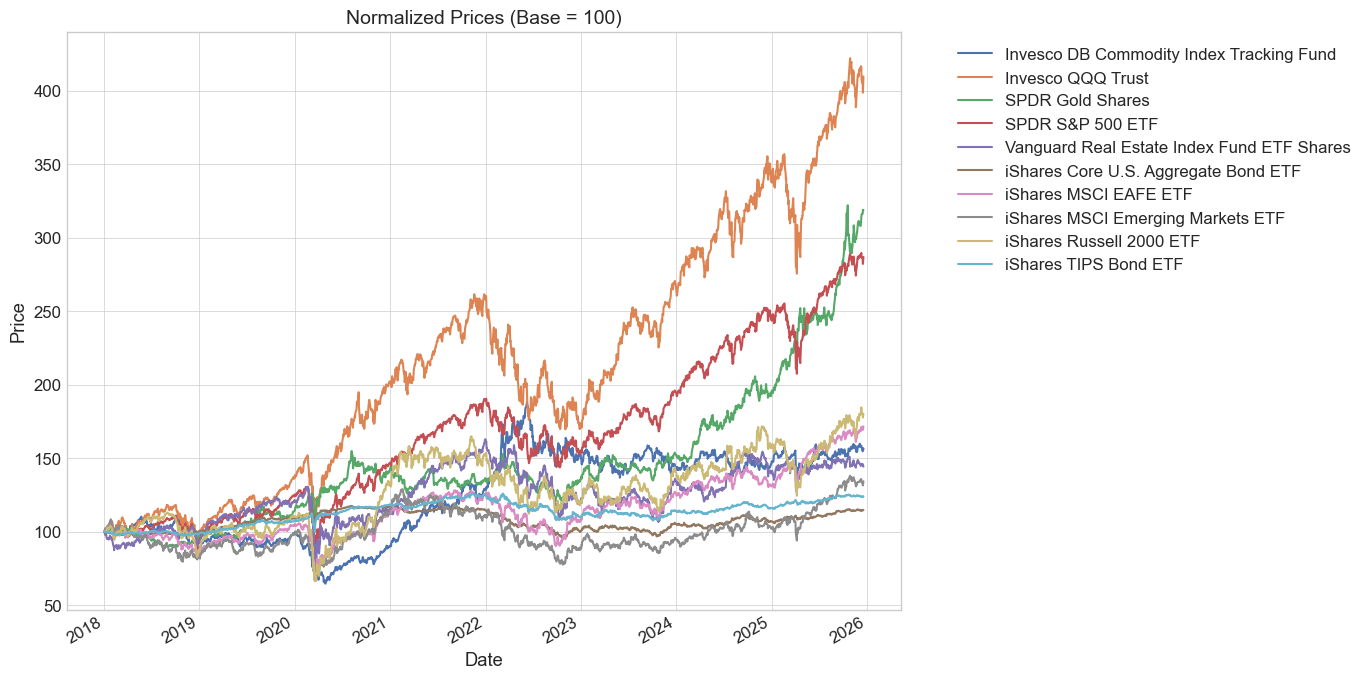

In [15]:
# Plot normalized prices
normalized = prices / prices.iloc[0] * 100
fig, ax = plt.subplots(figsize=(14, 7))
normalized.plot(ax=ax)
ax.set_title('Normalized Prices (Base = 100)', fontsize=14)
ax.set_ylabel('Price')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 3. Returns Calculation <a id='returns-calculation'></a>

Calculate returns in various formats and frequencies.

In [16]:
from myPortfolioManagement.myReturns import (
    calculate_returns,
    average_returns,
    convert_returns_freq,
    calculate_portfolio_returns
)

In [17]:
# Daily returns
returns_daily = calculate_returns(prices, log_returns=False)
print(f"Daily returns shape: {returns_daily.shape}")
print("\nDaily returns statistics:")
returns_daily.describe().T[['mean', 'std', 'min', 'max']]

Daily returns shape: (2003, 10)

Daily returns statistics:


,mean,std,min,max
longname,,,,
Invesco DB Commodity Index Tracking Fund,0.0003,0.0114,-0.0794,0.0480
Invesco QQQ Trust,0.0008,0.0152,-0.1198,0.1200
SPDR Gold Shares,0.0006,0.0095,-0.0643,0.0485
SPDR S&P 500 ETF,0.0006,0.0123,-0.1094,0.1050
Vanguard Real Estate Index Fund ETF Shares,0.0003,0.0140,-0.1773,0.0900
iShares Core U.S. Aggregate Bond ETF,0.0001,0.0037,-0.0400,0.0237
iShares MSCI EAFE ETF,0.0003,0.0113,-0.1099,0.0847
iShares MSCI Emerging Markets ETF,0.0002,0.0132,-0.1248,0.0805
iShares Russell 2000 ETF,0.0004,0.0155,-0.1327,0.0915


In [18]:
# Log returns
returns_log = calculate_returns(prices, log_returns=True)
print("Log returns statistics:")
returns_log.describe().T[['mean', 'std', 'min', 'max']]

Log returns statistics:


,mean,std,min,max
longname,,,,
Invesco DB Commodity Index Tracking Fund,0.0002,0.0115,-0.0828,0.0469
Invesco QQQ Trust,0.0007,0.0152,-0.1276,0.1134
SPDR Gold Shares,0.0006,0.0095,-0.0664,0.0474
SPDR S&P 500 ETF,0.0005,0.0123,-0.1159,0.0999
Vanguard Real Estate Index Fund ETF Shares,0.0002,0.0142,-0.1951,0.0861
iShares Core U.S. Aggregate Bond ETF,0.0001,0.0037,-0.0408,0.0234
iShares MSCI EAFE ETF,0.0003,0.0114,-0.1164,0.0813
iShares MSCI Emerging Markets ETF,0.0001,0.0133,-0.1333,0.0775
iShares Russell 2000 ETF,0.0003,0.0156,-0.1423,0.0875


In [19]:
# Monthly returns
returns_monthly = calculate_returns(prices, convert_to='monthly')
print(f"Monthly returns shape: {returns_monthly.shape}")
print("\nLast 12 months:")
returns_monthly.tail(12)

Monthly returns shape: (96, 10)

Last 12 months:


longname,Invesco DB Commodity Index Tracking Fund,Invesco QQQ Trust,SPDR Gold Shares,SPDR S&P 500 ETF,Vanguard Real Estate Index Fund ETF Shares,iShares Core U.S. Aggregate Bond ETF,iShares MSCI EAFE ETF,iShares MSCI Emerging Markets ETF,iShares Russell 2000 ETF,iShares TIPS Bond ETF
Date,,,,,,,,,,
2025-01-31,0.0276,0.0216,0.0679,0.0269,0.0165,0.0052,0.0480,0.0215,0.0250,0.0137
2025-02-28,0.0014,-0.0270,0.0182,-0.0127,0.0370,0.0224,0.0295,0.0115,-0.0522,0.0216
2025-03-31,0.0227,-0.0759,0.0945,-0.0557,-0.0259,-0.0003,0.0018,0.0113,-0.0685,0.0068
2025-04-30,-0.0858,0.0140,0.0542,-0.0087,-0.0244,0.0043,0.0370,0.0014,-0.0232,0.0013
2025-05-31,0.0151,0.0918,-0.0006,0.0628,0.0112,-0.0061,0.0479,0.0402,0.0524,-0.0063
2025-06-30,0.0445,0.0639,0.0041,0.0514,0.0069,0.0146,0.0240,0.0700,0.0552,0.0094
2025-07-31,0.0293,0.0242,-0.0061,0.0230,0.0009,-0.0026,-0.0209,0.0066,0.0167,0.0001
2025-08-31,-0.0107,0.0095,0.0499,0.0205,0.0348,0.0119,0.0452,0.0268,0.0719,0.0161
2025-09-30,0.0144,0.0538,0.1176,0.0356,0.0006,0.0113,0.0207,0.0710,0.0318,0.0042


In [20]:
# Expected returns (different methods)
mu_hist = average_returns(returns_daily, method='hist', periods=252)
mu_ema = average_returns(returns_daily, method='ema', span=500, periods=252)

expected_returns = pd.DataFrame({
    'Historical': mu_hist,
    'EMA': mu_ema
}).sort_values('Historical', ascending=False)

print("Expected Annual Returns:")
expected_returns

Expected Annual Returns:


,Historical,EMA
longname,,
Invesco QQQ Trust,0.1941,0.2745
SPDR Gold Shares,0.1571,0.4927
SPDR S&P 500 ETF,0.1418,0.2201
iShares Russell 2000 ETF,0.0769,0.2033
iShares MSCI EAFE ETF,0.0704,0.2025
Invesco DB Commodity Index Tracking Fund,0.0581,0.0589
Vanguard Real Estate Index Fund ETF Shares,0.0473,0.0421
iShares MSCI Emerging Markets ETF,0.0379,0.2174
iShares TIPS Bond ETF,0.0274,0.0405


In [21]:
# Get benchmark returns
benchmark_sp500 = get_benchmark_returns_fixed('^GSPC', 'S&P500')
print(f"S&P 500 benchmark shape: {benchmark_sp500.shape}")
print("\nLast 5 days:")
benchmark_sp500.tail()

YF.download() has changed argument auto_adjust default to True
YF deprecation warning: set proxy via new config function: yf.set_config(proxy=proxy)


[*********************100%***********************]  1 of 1 completed

S&P 500 benchmark shape: (24610, 1)

Last 5 days:


,S&P500
Date,
2025-12-15,-0.0016
2025-12-16,-0.0024
2025-12-17,-0.0116
2025-12-18,0.0079
2025-12-19,0.0088


## 4. Utility Functions <a id='utility-functions'></a>

Data quality checks and helper functions.

In [22]:
from myPortfolioManagement.myUtils import (
    data_overview,
    balance_dates,
    check_date_index,
    cap_outliersTS
)

In [23]:
# Data overview (convert to long format first)
prices_long = prices.reset_index().melt(
    id_vars='Date', 
    var_name='asset', 
    value_name='price'
)

overview = data_overview(
    prices_long,
    my_assets_col_name='asset',
    my_date_col_name='Date',
    price_col_name='price'
)

print("Data Overview:")
overview

Data Overview:


,Date_min,Date_max,trading_days,years_available,percentage_of_NAs
asset,,,,,
Invesco DB Commodity Index Tracking Fund,2018-01-02,2025-12-19,2908,7.9671,0.0000
Invesco QQQ Trust,2018-01-02,2025-12-19,2908,7.9671,0.0000
SPDR Gold Shares,2018-01-02,2025-12-19,2908,7.9671,0.0000
SPDR S&P 500 ETF,2018-01-02,2025-12-19,2908,7.9671,0.0000
Vanguard Real Estate Index Fund ETF Shares,2018-01-02,2025-12-19,2908,7.9671,0.0000
iShares Core U.S. Aggregate Bond ETF,2018-01-02,2025-12-19,2908,7.9671,0.0000
iShares MSCI EAFE ETF,2018-01-02,2025-12-19,2908,7.9671,0.0000
iShares MSCI Emerging Markets ETF,2018-01-02,2025-12-19,2908,7.9671,0.0000
iShares Russell 2000 ETF,2018-01-02,2025-12-19,2908,7.9671,0.0000


In [24]:
# Balance dates between returns and benchmark
returns_balanced, benchmark_balanced = balance_dates(returns_daily, benchmark_sp500)
print(f"Balanced returns shape: {returns_balanced.shape}")
print(f"Balanced benchmark shape: {benchmark_balanced.shape}")

Balanced returns shape: (2003, 10)
Balanced benchmark shape: (2003, 1)


## 5. Portfolio Optimization <a id='portfolio-optimization'></a>

Generate optimal portfolios using various methods.

In [25]:
from myPortfolioManagement.myPortfolioOptimisation import (
    HRP,
    equal_weight_portfolio,
    inverse_vol_portfolio,
    port_GMV,
    port_max_sharpe,
    port_target_return,
    port_target_volatility,
    port_CVAR,
    generate_rp_portfolios,
    make_standard_portfolios,
    risk_contributions
)

# Prepare returns for optimization (fill NaN with 0)
returns_opt = returns_daily.fillna(0)
print("Ready for optimization!")

Ready for optimization!


In [26]:
# Equal Weight Portfolio
weights_equal = equal_weight_portfolio(returns_opt)
print("Equal Weight Portfolio:")
weights_equal

Equal Weight Portfolio:


,port_naive
assets,
Invesco DB Commodity Index Tracking Fund,0.1000
Invesco QQQ Trust,0.1000
SPDR Gold Shares,0.1000
SPDR S&P 500 ETF,0.1000
Vanguard Real Estate Index Fund ETF Shares,0.1000
iShares Core U.S. Aggregate Bond ETF,0.1000
iShares MSCI EAFE ETF,0.1000
iShares MSCI Emerging Markets ETF,0.1000
iShares Russell 2000 ETF,0.1000


In [27]:
# Inverse Volatility Portfolio
weights_inv_vol = inverse_vol_portfolio(returns_opt, weight_max=0.25)
print("Inverse Volatility Portfolio:")
weights_inv_vol.sort_values('port_inverse_vol', ascending=False)

Inverse Volatility Portfolio:


,port_inverse_vol
asset,
iShares Core U.S. Aggregate Bond ETF,0.2325
iShares TIPS Bond ETF,0.2208
SPDR Gold Shares,0.0901
iShares MSCI EAFE ETF,0.0753
Invesco DB Commodity Index Tracking Fund,0.0748
SPDR S&P 500 ETF,0.0696
iShares MSCI Emerging Markets ETF,0.0647
Vanguard Real Estate Index Fund ETF Shares,0.0609
Invesco QQQ Trust,0.0563


In [28]:
# Hierarchical Risk Parity (HRP)
weights_hrp = HRP(
    model='HRP',
    returns_training=returns_opt,
    codependence='pearson',
    covariance='ledoit',
    rm='MV',
    linkage='ward',
    weight_max=0.25,
    weight_min=0.02
)
print("HRP Portfolio:")
weights_hrp.sort_values('port_weight', ascending=False)

HRP Portfolio:


,port_weight
iShares TIPS Bond ETF,0.2500
iShares Core U.S. Aggregate Bond ETF,0.2500
SPDR S&P 500 ETF,0.2415
SPDR Gold Shares,0.0938
Invesco DB Commodity Index Tracking Fund,0.0647
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200
iShares Russell 2000 ETF,0.0200


In [29]:
# HERC (Hierarchical Equal Risk Contribution)
weights_herc = HRP(
    model='HERC',
    returns_training=returns_opt,
    codependence='pearson',
    rm='CVaR',
    weight_max=0.30,
    weight_min=0.02
)
print("HERC Portfolio:")
weights_herc.sort_values('port_weight', ascending=False)

HERC Portfolio:


,port_weight
iShares Core U.S. Aggregate Bond ETF,0.2421
iShares TIPS Bond ETF,0.2312
SPDR Gold Shares,0.1795
Invesco DB Commodity Index Tracking Fund,0.1746
iShares MSCI EAFE ETF,0.0344
SPDR S&P 500 ETF,0.0302
iShares MSCI Emerging Markets ETF,0.0301
Vanguard Real Estate Index Fund ETF Shares,0.0274
iShares Russell 2000 ETF,0.0253
Invesco QQQ Trust,0.0251


In [30]:
# Global Minimum Variance
weights_gmv = port_GMV(returns_opt, weight_min=0.02, weight_max=0.30)
print("Global Minimum Variance Portfolio:")
weights_gmv.sort_values('port_min_vol', ascending=False)

Global Minimum Variance Portfolio:


,port_min_vol
assets,
iShares Core U.S. Aggregate Bond ETF,0.3000
iShares TIPS Bond ETF,0.3000
SPDR Gold Shares,0.1638
Invesco DB Commodity Index Tracking Fund,0.1116
SPDR S&P 500 ETF,0.0246
Invesco QQQ Trust,0.0200
Vanguard Real Estate Index Fund ETF Shares,0.0200
iShares MSCI EAFE ETF,0.0200
iShares MSCI Emerging Markets ETF,0.0200


In [31]:
# Maximum Sharpe Ratio
weights_max_sharpe = port_max_sharpe(returns_opt, rf=0.04, weight_min=0.02, weight_max=0.30)
print("Max Sharpe Portfolio:")
weights_max_sharpe.sort_values('port_max_Sharpe', ascending=False)

Max Sharpe Portfolio:


,asset,port_max_Sharpe
2,SPDR Gold Shares,0.3000
9,iShares TIPS Bond ETF,0.3000
1,Invesco QQQ Trust,0.2096
5,iShares Core U.S. Aggregate Bond ETF,0.0704
0,Invesco DB Commodity Index Tracking Fund,0.0200
3,SPDR S&P 500 ETF,0.0200
4,Vanguard Real Estate Index Fund ETF Shares,0.0200
6,iShares MSCI EAFE ETF,0.0200
7,iShares MSCI Emerging Markets ETF,0.0200
8,iShares Russell 2000 ETF,0.0200


In [32]:
# Minimum CVaR Portfolio
weights_cvar = port_CVAR(returns_opt, confidence_interval=0.95, rf=0.04, 
                         weight_min=0.02, weight_max=0.30)
print("Minimum CVaR Portfolio:")
weights_cvar.sort_values('port_target_CVAR', ascending=False)

Minimum CVaR Portfolio:


,asset,port_target_CVAR
5,iShares Core U.S. Aggregate Bond ETF,0.3000
9,iShares TIPS Bond ETF,0.3000
2,SPDR Gold Shares,0.1836
0,Invesco DB Commodity Index Tracking Fund,0.0913
3,SPDR S&P 500 ETF,0.0250
1,Invesco QQQ Trust,0.0200
4,Vanguard Real Estate Index Fund ETF Shares,0.0200
6,iShares MSCI EAFE ETF,0.0200
7,iShares MSCI Emerging Markets ETF,0.0200
8,iShares Russell 2000 ETF,0.0200


In [34]:
# Compare all portfolios
# First, let's inspect the structure of each weights dataframe
print("Inspecting weight dataframes...")
print("\nweights_equal columns:", weights_equal.columns.tolist())
print("weights_inv_vol columns:", weights_inv_vol.columns.tolist())
print("weights_hrp columns:", weights_hrp.columns.tolist())
print("weights_herc columns:", weights_herc.columns.tolist())
print("weights_gmv columns:", weights_gmv.columns.tolist())
print("weights_max_sharpe columns:", weights_max_sharpe.columns.tolist())
print("weights_cvar columns:", weights_cvar.columns.tolist())

# Now build the comparison dataframe more robustly
all_weights = pd.DataFrame(index=weights_hrp.index)

# Extract weights, handling different column names
all_weights['Equal'] = weights_equal['port_naive'].values if 'port_naive' in weights_equal.columns else weights_equal.iloc[:, -1].values
all_weights['Inv_Vol'] = weights_inv_vol['port_inverse_vol'].values if 'port_inverse_vol' in weights_inv_vol.columns else weights_inv_vol.iloc[:, -1].values
all_weights['HRP'] = weights_hrp['port_weight'].values if 'port_weight' in weights_hrp.columns else weights_hrp.iloc[:, -1].values
all_weights['HERC'] = weights_herc['port_weight'].values if 'port_weight' in weights_herc.columns else weights_herc.iloc[:, -1].values

# For GMV, Max_Sharpe, and CVaR - handle cases where 'asset' might be index or column
if 'asset' in weights_gmv.columns:
    all_weights['GMV'] = weights_gmv.set_index('asset')['port_min_vol']
else:
    all_weights['GMV'] = weights_gmv['port_min_vol'].values if 'port_min_vol' in weights_gmv.columns else weights_gmv.iloc[:, -1].values

if 'asset' in weights_max_sharpe.columns:
    all_weights['Max_Sharpe'] = weights_max_sharpe.set_index('asset')['port_max_Sharpe']
else:
    all_weights['Max_Sharpe'] = weights_max_sharpe['port_max_Sharpe'].values if 'port_max_Sharpe' in weights_max_sharpe.columns else weights_max_sharpe.iloc[:, -1].values

if 'asset' in weights_cvar.columns:
    all_weights['Min_CVaR'] = weights_cvar.set_index('asset')['port_target_CVAR']
else:
    all_weights['Min_CVaR'] = weights_cvar['port_target_CVAR'].values if 'port_target_CVAR' in weights_cvar.columns else weights_cvar.iloc[:, -1].values

print("\nAll Portfolio Weights Comparison:")
all_weights.round(3)

Inspecting weight dataframes...

weights_equal columns: ['port_naive']
weights_inv_vol columns: ['port_inverse_vol']
weights_hrp columns: ['port_weight']
weights_herc columns: ['port_weight']
weights_gmv columns: ['port_min_vol']
weights_max_sharpe columns: ['asset', 'port_max_Sharpe']
weights_cvar columns: ['asset', 'port_target_CVAR']

All Portfolio Weights Comparison:


,Equal,Inv_Vol,HRP,HERC,GMV,Max_Sharpe,Min_CVaR
Invesco DB Commodity Index Tracking Fund,0.1000,0.0750,0.0650,0.1750,0.1120,0.0200,0.0910
Invesco QQQ Trust,0.1000,0.0560,0.0200,0.0250,0.0200,0.2100,0.0200
SPDR Gold Shares,0.1000,0.0900,0.0940,0.1800,0.1640,0.3000,0.1840
SPDR S&P 500 ETF,0.1000,0.0700,0.2420,0.0300,0.0250,0.0200,0.0250
Vanguard Real Estate Index Fund ETF Shares,0.1000,0.0610,0.0200,0.0270,0.0200,0.0200,0.0200
iShares Core U.S. Aggregate Bond ETF,0.1000,0.2320,0.2500,0.2420,0.3000,0.0700,0.3000
iShares MSCI EAFE ETF,0.1000,0.0750,0.0200,0.0340,0.0200,0.0200,0.0200
iShares MSCI Emerging Markets ETF,0.1000,0.0650,0.0200,0.0300,0.0200,0.0200,0.0200
iShares Russell 2000 ETF,0.1000,0.0550,0.0200,0.0250,0.0200,0.0200,0.0200
iShares TIPS Bond ETF,0.1000,0.2210,0.2500,0.2310,0.3000,0.3000,0.3000


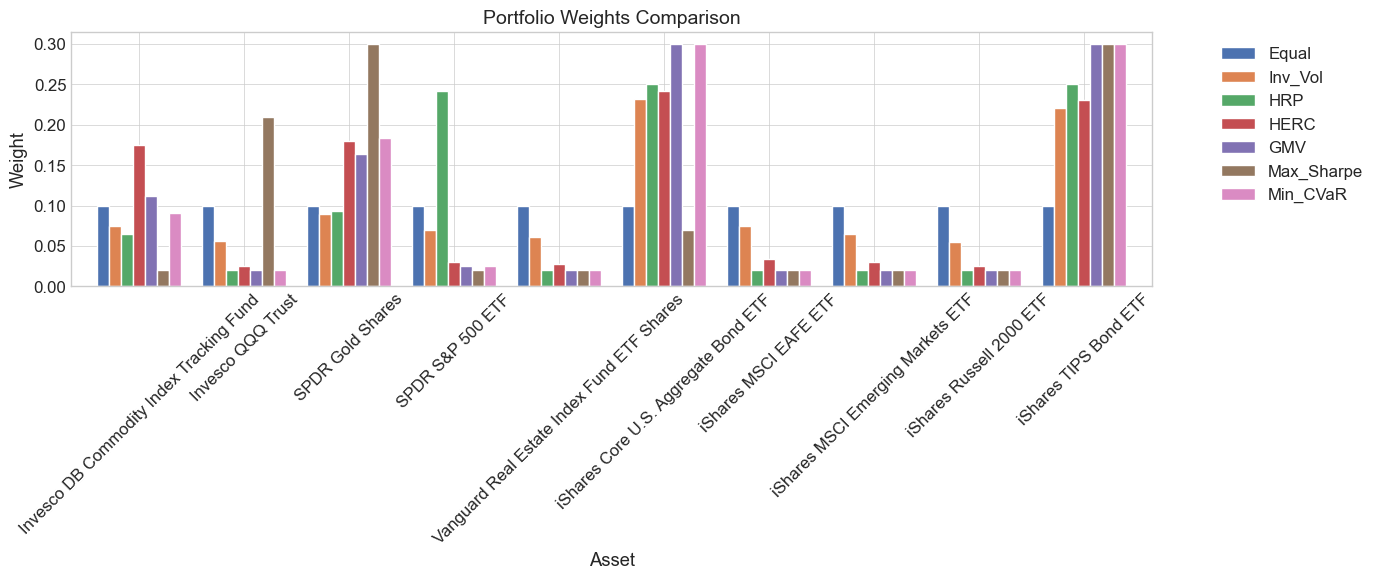

In [35]:
# Visualize weights comparison
fig, ax = plt.subplots(figsize=(14, 6))
all_weights.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Portfolio Weights Comparison', fontsize=14)
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [76]:
# Calculate portfolio returns using optimized weights
print("Calculating portfolio returns using optimized weights...\n")

# Create a dictionary to store portfolio returns
portfolio_returns_dict = {}

# HRP Portfolio
hrp_weights = weights_hrp['port_weight'].to_dict()
portfolio_returns_dict['HRP'] = (returns_daily * pd.Series(hrp_weights)).sum(axis=1)

# HERC Portfolio
herc_weights = weights_herc['port_weight'].to_dict()
portfolio_returns_dict['HERC'] = (returns_daily * pd.Series(herc_weights)).sum(axis=1)

# Equal Weight Portfolio
equal_weights = weights_equal['port_naive'].to_dict()
portfolio_returns_dict['Equal_Weight'] = (returns_daily * pd.Series(equal_weights)).sum(axis=1)

# Inverse Volatility Portfolio
inv_vol_weights = weights_inv_vol['port_inverse_vol'].to_dict()
portfolio_returns_dict['Inv_Vol'] = (returns_daily * pd.Series(inv_vol_weights)).sum(axis=1)

# GMV Portfolio
gmv_weights = weights_gmv['port_min_vol'].to_dict()
portfolio_returns_dict['GMV'] = (returns_daily * pd.Series(gmv_weights)).sum(axis=1)

# Max Sharpe Portfolio
max_sharpe_weights = weights_max_sharpe['port_max_Sharpe'].to_dict()
portfolio_returns_dict['Max_Sharpe'] = (returns_daily * pd.Series(max_sharpe_weights)).sum(axis=1)

# Min CVaR Portfolio
cvar_weights = weights_cvar['port_target_CVAR'].to_dict()
portfolio_returns_dict['Min_CVaR'] = (returns_daily * pd.Series(cvar_weights)).sum(axis=1)

# Combine into DataFrame
portfolio_returns_comparison = pd.DataFrame(portfolio_returns_dict)

# Calculate cumulative returns (growth of $1)
cum_portfolio_returns = (1 + portfolio_returns_comparison).cumprod()

print("Portfolio Cumulative Performance Summary:")
print(cum_portfolio_returns.iloc[-1].round(4))

# Recalculate max drawdown properly
max_drawdowns = {}
for col in portfolio_returns_comparison.columns:
    cum_ret = (1 + portfolio_returns_comparison[col]).cumprod()
    running_max = cum_ret.expanding().max()
    drawdown = (cum_ret - running_max) / running_max
    max_drawdowns[col] = drawdown.min()

print("\nPerformance Metrics:")
metrics_df = pd.DataFrame({
    'Annual Return': portfolio_returns_comparison.mean() * 252,
    'Annual Volatility': portfolio_returns_comparison.std() * np.sqrt(252),
    'Sharpe Ratio': (portfolio_returns_comparison.mean() * 252) / (portfolio_returns_comparison.std() * np.sqrt(252)),
    'Max Drawdown': pd.Series(max_drawdowns)
})
print(metrics_df.round(4))

Calculating portfolio returns using optimized weights...

Portfolio Cumulative Performance Summary:
HRP            1.8156
HERC           1.7209
Equal_Weight   1.9982
Inv_Vol        1.7263
GMV            1.6146
Max_Sharpe     1.0000
Min_CVaR       1.0000
Name: 2025-12-19 00:00:00, dtype: float64

Performance Metrics:
              Annual Return  Annual Volatility  Sharpe Ratio  Max Drawdown
HRP                  0.0786             0.0845        0.9305       -0.1671
HERC                 0.0713             0.0776        0.9191       -0.1563
Equal_Weight         0.0956             0.1299        0.7356       -0.2466
Inv_Vol              0.0729             0.0916        0.7958       -0.1867
GMV                  0.0626             0.0674        0.9282       -0.1449
Max_Sharpe           0.0000             0.0000           NaN        0.0000
Min_CVaR             0.0000             0.0000           NaN        0.0000


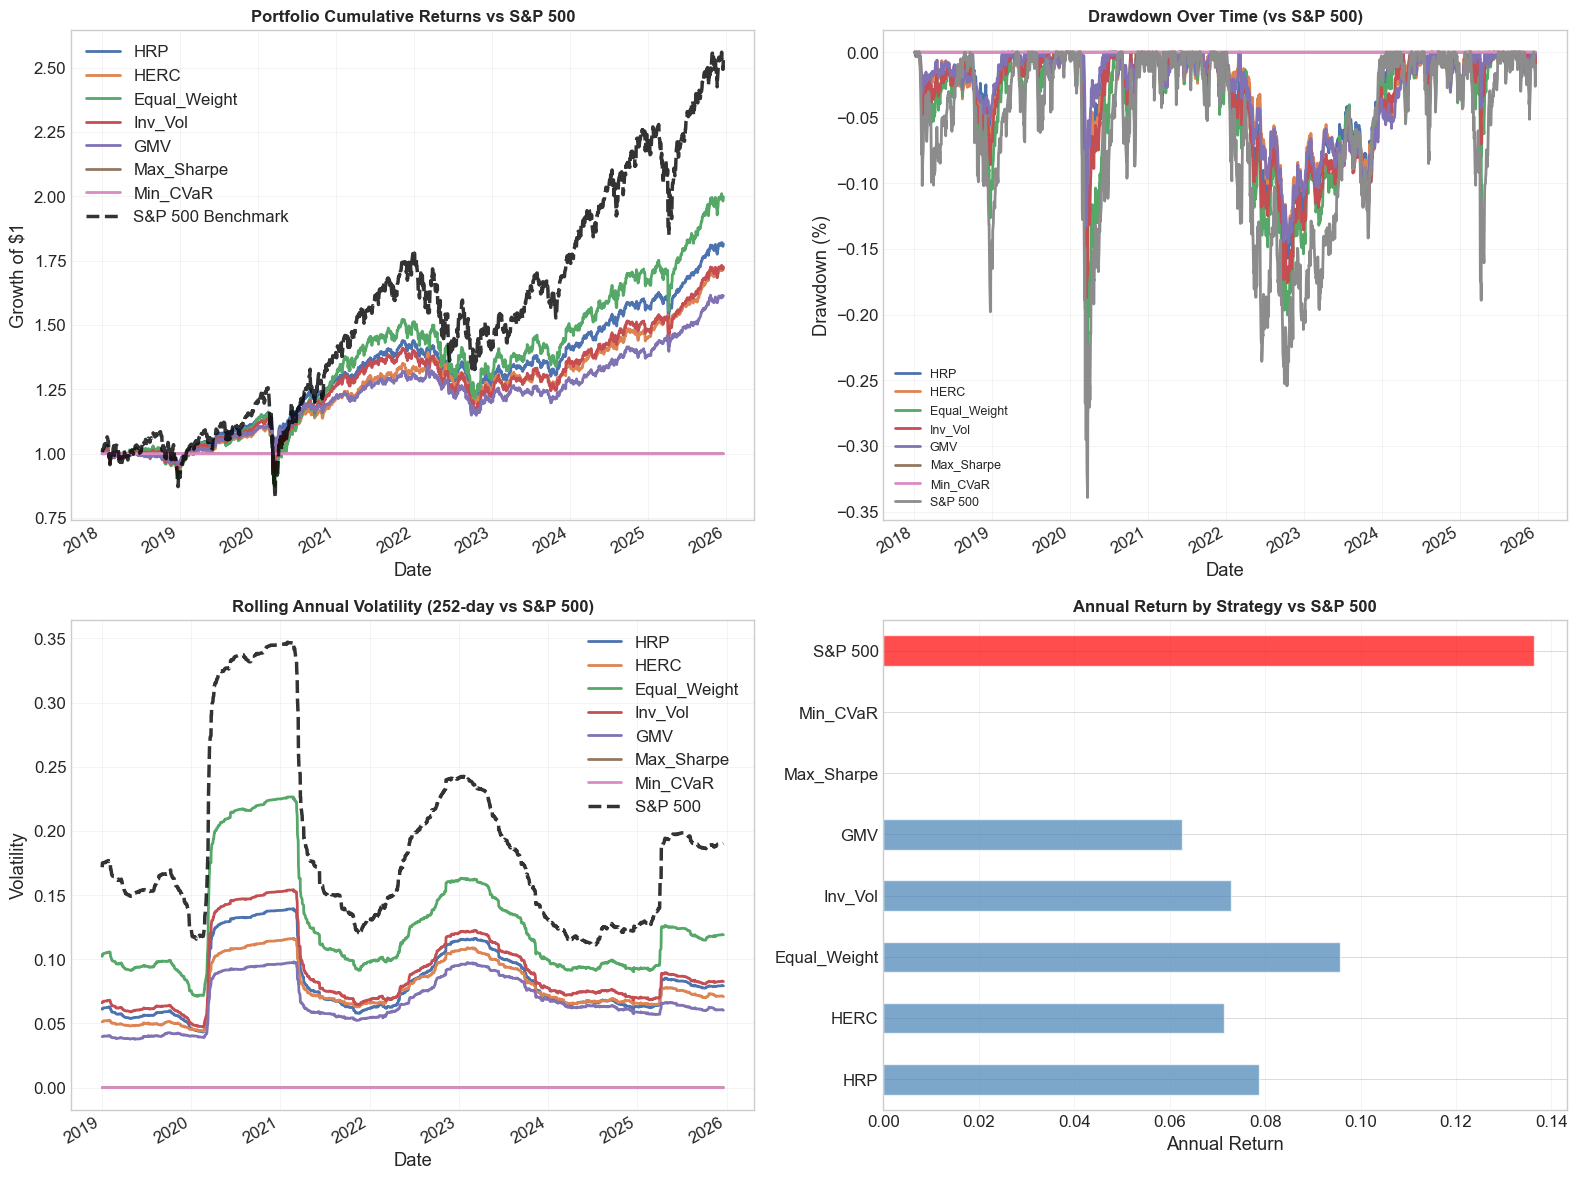


Visualization complete!

Benchmark (S&P 500) Metrics:
         Annual Return  Annual Volatility  Sharpe Ratio  Max Drawdown
S&P 500         0.1364             0.1963        0.6948       -0.3392


In [78]:
# Visualize cumulative returns for all portfolios vs S&P 500 benchmark
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Align benchmark returns with portfolio returns
benchmark_aligned = benchmark_sp500.squeeze().loc[portfolio_returns_comparison.index]
benchmark_cum = (1 + benchmark_aligned).cumprod()

# Plot 1: Cumulative Returns vs Benchmark
ax = axes[0, 0]
cum_portfolio_returns.plot(ax=ax, linewidth=2, label='Portfolios')
benchmark_cum.plot(ax=ax, linewidth=2.5, linestyle='--', color='black', label='S&P 500 Benchmark', alpha=0.8)
ax.set_title('Portfolio Cumulative Returns vs S&P 500', fontsize=12, fontweight='bold')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Plot 2: Drawdown Comparison (Portfolios + Benchmark)
ax = axes[0, 1]
drawdowns = {}
for col in portfolio_returns_comparison.columns:
    cum_ret = (1 + portfolio_returns_comparison[col]).cumprod()
    running_max = cum_ret.expanding().max()
    drawdowns[col] = (cum_ret - running_max) / running_max

# Add benchmark drawdown
bench_running_max = benchmark_cum.expanding().max()
drawdowns['S&P 500'] = (benchmark_cum - bench_running_max) / bench_running_max

drawdowns_df = pd.DataFrame(drawdowns)
drawdowns_df.plot(ax=ax, linewidth=2)
ax.set_title('Drawdown Over Time (vs S&P 500)', fontsize=12, fontweight='bold')
ax.set_ylabel('Drawdown (%)')
ax.set_xlabel('Date')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: Rolling Volatility (252-day window) vs Benchmark
ax = axes[1, 0]
rolling_vol = portfolio_returns_comparison.rolling(252).std() * np.sqrt(252)
bench_rolling_vol = benchmark_aligned.rolling(252).std() * np.sqrt(252)

rolling_vol.plot(ax=ax, linewidth=2, label='Portfolios')
bench_rolling_vol.plot(ax=ax, linewidth=2.5, linestyle='--', color='black', label='S&P 500', alpha=0.8)
ax.set_title('Rolling Annual Volatility (252-day vs S&P 500)', fontsize=12, fontweight='bold')
ax.set_ylabel('Volatility')
ax.set_xlabel('Date')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Plot 4: Performance Metrics Comparison (Including S&P 500)
ax = axes[1, 1]
benchmark_metrics = pd.DataFrame({
    'Annual Return': [benchmark_aligned.mean() * 252],
    'Annual Volatility': [benchmark_aligned.std() * np.sqrt(252)],
    'Sharpe Ratio': [(benchmark_aligned.mean() * 252) / (benchmark_aligned.std() * np.sqrt(252))],
    'Max Drawdown': [drawdowns['S&P 500'].min()]
}, index=['S&P 500'])

metrics_comparison = pd.concat([metrics_df, benchmark_metrics])
metrics_comparison['Annual Return'].plot(kind='barh', ax=ax, color=['steelblue']*len(metrics_df) + ['red'], alpha=0.7)
ax.set_title('Annual Return by Strategy vs S&P 500', fontsize=12, fontweight='bold')
ax.set_xlabel('Annual Return')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")
print("\nBenchmark (S&P 500) Metrics:")
print(benchmark_metrics.round(4))

## 6. Performance Metrics <a id='performance-metrics'></a>

Calculate comprehensive performance metrics.

In [36]:
from myPortfolioManagement.myPerformanceMetrics import (
    get_main_stats,
    alpha_beta_table,
    alpha_beta_bull,
    alpha_beta_bear,
    information_ratio,
    drawdown_details,
    assets_drawdown_details,
    performance_overview,
    cagr,
    beta_Co_Moments_table
)

In [37]:
# Main performance statistics
main_stats = get_main_stats(returns_daily, rf=0.04, smart=True)
print("Main Performance Stats:")
main_stats.round(4)

get_main_stats took 167.89ms
Main Performance Stats:


,total_ret,cagr,adjusted_sortino,sharpe,calmar,max_drawdown
Invesco DB Commodity Index Tracking Fund,0.5667,0.0580,0.2778,0.2923,0.1391,-0.4171
Invesco QQQ Trust,3.0971,0.1939,0.8583,0.8594,0.5520,-0.3512
SPDR Gold Shares,2.1883,0.1568,1.0159,0.9980,0.7128,-0.2200
SPDR S&P 500 ETF,1.8692,0.1416,0.7287,0.7375,0.4200,-0.3372
Vanguard Real Estate Index Fund ETF Shares,0.4436,0.0472,0.2200,0.2289,0.1113,-0.4240
iShares Core U.S. Aggregate Bond ETF,0.1478,0.0175,-0.1517,-0.1588,0.0948,-0.1843
iShares MSCI EAFE ETF,0.7168,0.0703,0.3559,0.3667,0.2055,-0.3419
iShares MSCI Emerging Markets ETF,0.3436,0.0378,0.1724,0.1770,0.0949,-0.3982
iShares Russell 2000 ETF,0.8025,0.0768,0.3579,0.3632,0.1868,-0.4113
iShares TIPS Bond ETF,0.2399,0.0274,0.0352,0.0349,0.1888,-0.1451


In [38]:
# CAGR Calculation
cagr_values = cagr(prices)
print("Compound Annual Growth Rate:")
cagr_values.sort_values(ascending=False).round(4)

Compound Annual Growth Rate:


Invesco QQQ Trust                            0.1938
SPDR Gold Shares                             0.1568
SPDR S&P 500 ETF                             0.1416
iShares Russell 2000 ETF                     0.0768
iShares MSCI EAFE ETF                        0.0702
Invesco DB Commodity Index Tracking Fund     0.0580
Vanguard Real Estate Index Fund ETF Shares   0.0472
iShares MSCI Emerging Markets ETF            0.0378
iShares TIPS Bond ETF                        0.0274
iShares Core U.S. Aggregate Bond ETF         0.0175
dtype: float64

In [39]:
# Alpha-Beta Analysis (Full Market)
ab_table = alpha_beta_table(returns_daily, benchmark_sp500, rf=0.04)
print("Alpha-Beta Table (Full, Bull, Bear):")
ab_table

Alpha-Beta Table (Full, Bull, Bear):


,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear
asset,,,,,,
Invesco DB Commodity Index Tracking Fund,-1.0000,-0.9800,-0.9000,0.3200,0.2300,0.4700
Invesco QQQ Trust,3.7500,1.2500,0.2000,1.1500,1.1100,1.0900
SPDR Gold Shares,-1.0000,-0.9900,-0.9900,0.0700,0.1000,0.0600
SPDR S&P 500 ETF,-0.0700,-0.0300,-0.0500,0.9900,0.9900,0.9900
Vanguard Real Estate Index Fund ETF Shares,-0.7900,-0.6100,0.1300,0.8500,0.8600,0.9500
iShares Core U.S. Aggregate Bond ETF,-1.0000,-0.9900,-0.9900,0.0400,0.0400,0.0300
iShares MSCI EAFE ETF,-0.8900,-0.6900,-0.6100,0.7900,0.7600,0.8100
iShares MSCI Emerging Markets ETF,-0.8600,-0.6800,-0.6000,0.8100,0.7600,0.8300
iShares Russell 2000 ETF,1.3400,0.3000,0.3200,1.0900,1.0100,1.0900


In [40]:
# Information Ratio
info_ratio = information_ratio(returns_daily, benchmark_sp500.squeeze())
print("Information Ratio:")
info_ratio.round(4)

Information Ratio:


,information_ratio
assets,
Invesco DB Commodity Index Tracking Fund,-0.0183
Invesco QQQ Trust,0.0502
SPDR Gold Shares,0.0058
SPDR S&P 500 ETF,0.0929
Vanguard Real Estate Index Fund ETF Shares,-0.0269
iShares Core U.S. Aggregate Bond ETF,-0.0372
iShares MSCI EAFE ETF,-0.0317
iShares MSCI Emerging Markets ETF,-0.0342
iShares Russell 2000 ETF,-0.0157


In [41]:
# Drawdown Details (for first asset)
spy_prices = prices.iloc[:, 0]
dd_details = drawdown_details(spy_prices, top_drawdowns=5)
print(f"Top 5 Drawdowns for {prices.columns[0]}:")
dd_details

Top 5 Drawdowns for Invesco DB Commodity Index Tracking Fund:


,start,valley,end,days,Years,max drawdown,Peak Price,Bottom Price
11,2018-10-04,2020-04-27,2021-04-28,938,3,-42.0000,16.0000,9.0000
33,2022-06-10,2023-05-31,2025-12-19,1289,4,-27.0000,27.0000,20.0000
29,2022-03-09,2022-03-16,2022-04-13,36,0,-13.0000,23.0000,22.0000
23,2021-10-21,2021-12-01,2022-01-14,86,0,-12.0000,19.0000,17.0000
10,2018-05-24,2018-08-15,2018-10-02,132,0,-10.0000,16.0000,15.0000


In [42]:
# Performance Overview
perf_overview = performance_overview(returns_daily, prices=False, short=True)
print("Performance Overview:")
perf_overview.round(4)

Performance Overview:


,start,end,total_return,cagr,max_drawdown,yearly_sharpe,yearly_sortino,calmar
Invesco DB Commodity Index Tracking Fund,2018-01-03 00:00:00,2025-12-19 00:00:00,0.5573,0.0572,-0.4171,0.5694,2.7930,0.1372
Invesco QQQ Trust,2018-01-03 00:00:00,2025-12-19 00:00:00,3.0577,0.1924,-0.3512,0.9133,2.1325,0.5479
SPDR Gold Shares,2018-01-03 00:00:00,2025-12-19 00:00:00,2.1968,0.1572,-0.2200,0.8852,13.1073,0.7145
SPDR S&P 500 ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,1.8511,0.1407,-0.3372,1.0880,2.6756,0.4173
Vanguard Real Estate Index Fund ETF Shares,2018-01-03 00:00:00,2025-12-19 00:00:00,0.4478,0.0476,-0.4240,0.3758,0.8422,0.1122
iShares Core U.S. Aggregate Bond ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,0.1477,0.0175,-0.1843,0.2847,0.4489,0.0947
iShares MSCI EAFE ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,0.7086,0.0696,-0.3419,0.7761,2.0839,0.2036
iShares MSCI Emerging Markets ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,0.3308,0.0366,-0.3982,0.4934,1.0819,0.0918
iShares Russell 2000 ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,0.8007,0.0767,-0.4113,0.7893,1.5215,0.1865
iShares TIPS Bond ETF,2018-01-03 00:00:00,2025-12-19 00:00:00,0.2387,0.0273,-0.1451,0.4683,0.7660,0.1879


## 7. Low-Level Risk Metrics <a id='risk-metrics'></a>

Calculate individual risk and return metrics.

In [43]:
from myPortfolioManagement.metrics import (
    vol, beta, var, cvar, lpm, hpm,
    max_dd, dd, sharpe_ratio, sortino_ratio,
    treynor_ratio, calmar_ratio, omega_ratio,
    gain_loss_ratio, upside_potential_ratio
)

# Use SPY returns for demonstration
spy_returns = returns_daily.iloc[:, 0].dropna().values
market_returns = benchmark_sp500.squeeze().dropna().values

# Align lengths
min_len = min(len(spy_returns), len(market_returns))
spy_returns = spy_returns[:min_len]
market_returns = market_returns[:min_len]

In [44]:
# Basic risk metrics
print("Basic Risk Metrics:")
print(f"Volatility (annualized): {vol(spy_returns) * np.sqrt(252):.4f}")
print(f"Beta to market: {beta(spy_returns, market_returns):.4f}")
print(f"VaR (5%): {var(spy_returns, 0.05):.4f}")
print(f"CVaR (5%): {cvar(spy_returns, 0.05):.4f}")
print(f"Maximum Drawdown: {max_dd(spy_returns):.4f}")

Basic Risk Metrics:
Volatility (annualized): 0.1811
Beta to market: -0.0001
VaR (5%): 0.0179
CVaR (5%): 0.0278
Maximum Drawdown: 0.1185


In [45]:
# Risk-adjusted return ratios
er = np.mean(spy_returns) * 252  # Annualized expected return
rf = 0.04  # Risk-free rate

print("Risk-Adjusted Return Ratios:")
print(f"Sharpe Ratio: {sharpe_ratio(er, spy_returns, rf/252):.4f}")
print(f"Sortino Ratio: {sortino_ratio(er, spy_returns, rf/252):.4f}")
print(f"Treynor Ratio: {treynor_ratio(er, spy_returns, market_returns, rf/252):.4f}")
print(f"Calmar Ratio: {calmar_ratio(er, spy_returns, rf/252):.4f}")
print(f"Omega Ratio: {omega_ratio(er, spy_returns, rf/252):.4f}")
print(f"Gain/Loss Ratio: {gain_loss_ratio(spy_returns):.4f}")

Risk-Adjusted Return Ratios:
Sharpe Ratio: 6.3833
Sortino Ratio: 8.6287
Treynor Ratio: -713.2356
Calmar Ratio: 0.6144
Omega Ratio: 18.0469
Gain/Loss Ratio: 1.0718


## 8. Backtesting & Simulation <a id='backtesting'></a>

Monte Carlo simulation and portfolio backtesting.

In [46]:
from myPortfolioManagement.myBacktesting import (
    bootstrap_stats,
    bootstrap_portfolio_performance,
    sim_series,
    beating_probability,
    performance
)

# Create a simple portfolio return series
portfolio_returns = returns_daily.mean(axis=1)
portfolio_returns.name = 'Portfolio'

In [47]:
# Bootstrap statistics
print("Running bootstrap statistics (500 simulations)...")
bootstrap_results = bootstrap_stats(
    returns=portfolio_returns,
    returns_benchmark=benchmark_sp500.squeeze(),
    rf=0.04,
    periods=252,
    n_sim=500
)
print("\nBootstrap Statistics Distribution:")
bootstrap_results.describe().round(4)

Running bootstrap statistics (500 simulations)...
bootstrap_stats took 55.316sec

Bootstrap Statistics Distribution:


,cagr,volatility,sharpe,adjusted_sortino,alpha,beta
count,440.0000,440.0000,440.0000,440.0000,440.0000,440.0000
mean,0.0923,0.1296,0.4286,0.4054,-0.9801,0.6127
std,0.0344,0.0040,0.2361,0.2373,0.0015,0.0069
min,0.0284,0.1225,-0.0156,-0.0362,-0.9827,0.5990
25%,0.0638,0.1264,0.2453,0.2112,-0.9813,0.6067
50%,0.0923,0.1296,0.4230,0.4091,-0.9801,0.6127
75%,0.1180,0.1325,0.6103,0.5946,-0.9790,0.6180
max,0.1604,0.1377,0.8953,0.8956,-0.9772,0.6258


In [48]:
# Bootstrap portfolio performance (in-sample vs out-of-sample)
print("Running bootstrap performance analysis...")
try:
    means, distributions, dist_stats = bootstrap_portfolio_performance(
        returns=portfolio_returns,
        returns_benchmark=benchmark_sp500.squeeze(),
        periods=252,
        rf=0.04,
        out_of_sample_date='2023-01-01',
        n_sim=500
    )
    print("\nMean Performance Metrics:")
    print(means.round(4))
except Exception as e:
    print(f"Bootstrap performance analysis: {e}")

Running bootstrap performance analysis...
bootstrap_stats took 56.314sec
bootstrap_stats took 55.027sec
bootstrap_stats took 59.904sec
bootstrap_portfolio_performance took 171.264sec

Mean Performance Metrics:
                  in_sample  out_of_sample  all_sample
cagr                 0.0544         0.1589      0.0932
volatility           0.1422         0.1031      0.1293
sharpe               0.1689         1.0911      0.4454
adjusted_sortino     0.1618         1.1793      0.4286
alpha               -0.9795        -0.9823     -0.9799
beta                 0.6163         0.6009      0.6129


In [50]:
# Probability of beating benchmark
print("Calculating beating probability...")
try:
    beat_prob = beating_probability(
        returns=pd.DataFrame(portfolio_returns),
        returns_benchmark=benchmark_sp500,
        n_sample=500
    )
    print(f"\nProbability of beating S&P 500: {beat_prob.values[0][0]:.2%}")
except Exception as e:
    print(f"Beating probability calculation: {e}")

Calculating beating probability...

Probability of beating S&P 500: 49.00%


## 9. Bootstrapping <a id='bootstrapping'></a>

Time series bootstrapping methods.

In [51]:
from myPortfolioManagement.myBootstrapping import (
    BootstrapIDD,
    BootstrapStationary,
    BootstrapCircular,
    BootstrapMovingBlock,
    bootstrappingTS
)

# Use single asset returns for bootstrapping
single_returns = returns_daily.iloc[:, 0].dropna()

In [52]:
# IID Bootstrap
bs_iid = BootstrapIDD(series=single_returns, n_samples=100, seed=42)
print(f"IID Bootstrap shape: {bs_iid.shape}")
print(f"Original std: {single_returns.std():.6f}")
print(f"Bootstrap mean std: {bs_iid.std().mean():.6f}")

IID Bootstrap shape: (2003, 100)
Original std: 0.011412
Bootstrap mean std: 0.011369


In [53]:
# Stationary Bootstrap
bs_stationary = BootstrapStationary(
    series=single_returns,
    block_size=20,
    n_samples=100,
    seed=42
)
print(f"Stationary Bootstrap shape: {bs_stationary.shape}")

Stationary Bootstrap shape: (2003, 100)


In [54]:
# Circular Block Bootstrap
bs_circular = BootstrapCircular(
    series=single_returns,
    block_size=20,
    n_samples=100,
    seed=42
)
print(f"Circular Bootstrap shape: {bs_circular.shape}")

Circular Bootstrap shape: (2003, 100)


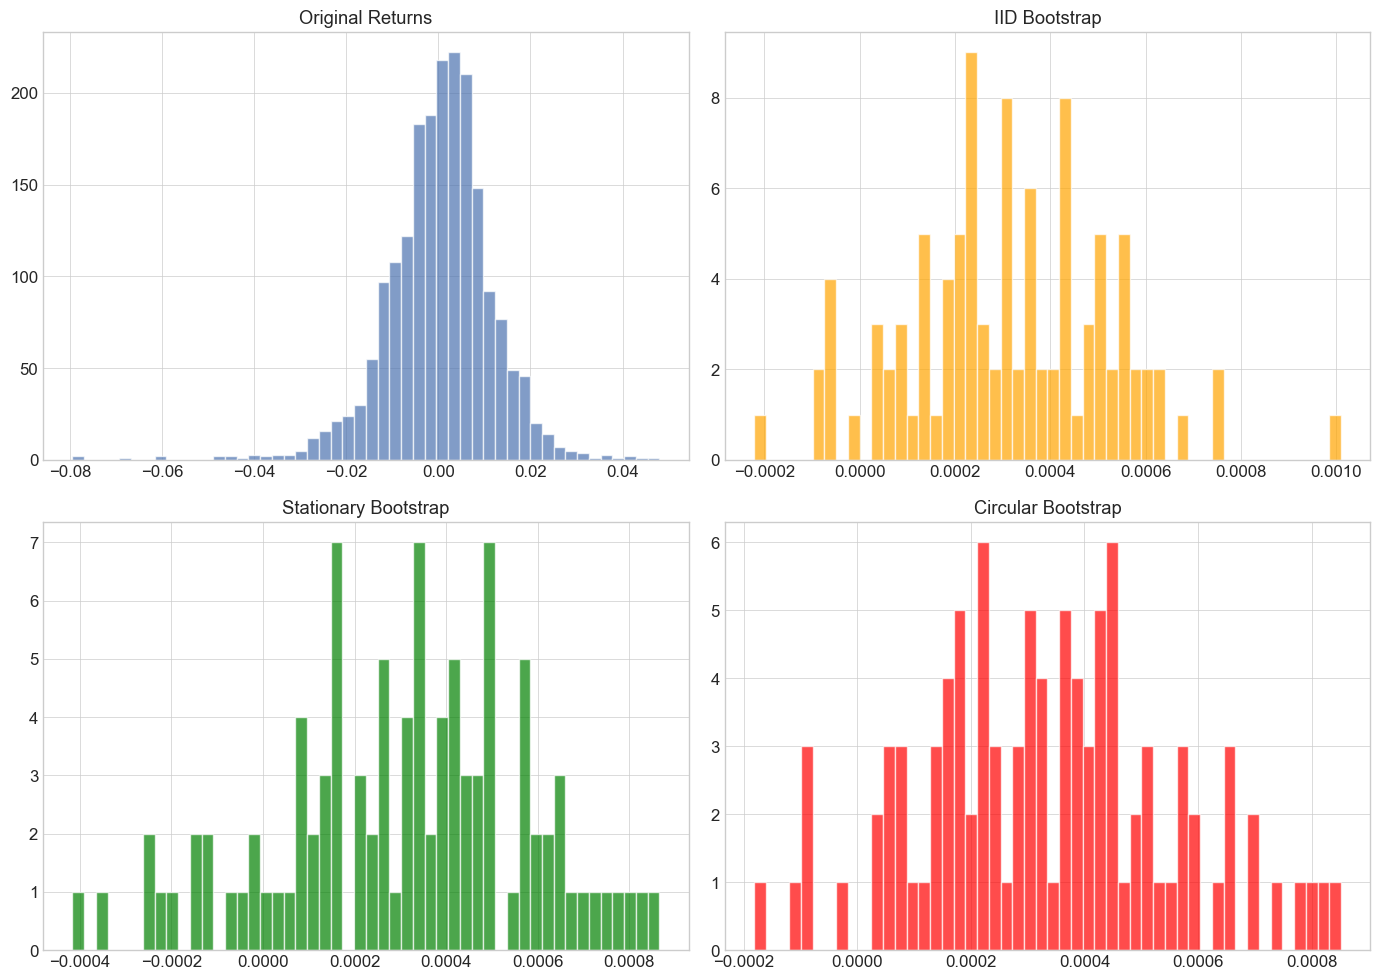

In [55]:
# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

single_returns.hist(bins=50, ax=axes[0, 0], alpha=0.7)
axes[0, 0].set_title('Original Returns')

bs_iid.mean().hist(bins=50, ax=axes[0, 1], alpha=0.7, color='orange')
axes[0, 1].set_title('IID Bootstrap')

bs_stationary.mean().hist(bins=50, ax=axes[1, 0], alpha=0.7, color='green')
axes[1, 0].set_title('Stationary Bootstrap')

bs_circular.mean().hist(bins=50, ax=axes[1, 1], alpha=0.7, color='red')
axes[1, 1].set_title('Circular Bootstrap')

plt.tight_layout()
plt.show()

## 10. Clustering & Regime Detection <a id='clustering'></a>

Asset clustering and market regime analysis.

In [56]:
from myPortfolioManagement.myClustering import (
    ts_clustering,
    cluster_ftca,
    detect_regimes
)

In [57]:
# Time Series Clustering (DTW)
print("Running time series clustering...")
try:
    clusters, cluster_centers = ts_clustering(
        df=prices,
        number_of_clusters=3,
        algo='dtw',
        plot_bar_center=False
    )
    print("\nAsset Clusters:")
    print(clusters)
    print(f"\nCluster Centers shape: {cluster_centers.shape}")
except Exception as e:
    print(f"Time series clustering: {e}")

Running time series clustering...

Asset Clusters:
                                           Cluster
asset                                             
Vanguard Real Estate Index Fund ETF Shares       1
iShares Core U.S. Aggregate Bond ETF             1
iShares TIPS Bond ETF                            1
iShares MSCI Emerging Markets ETF                2
Invesco DB Commodity Index Tracking Fund         3
Invesco QQQ Trust                                3
SPDR Gold Shares                                 3
SPDR S&P 500 ETF                                 3
iShares MSCI EAFE ETF                            3
iShares Russell 2000 ETF                         3

Cluster Centers shape: (2004, 3)


In [58]:
# FTCA Clustering
print("Running FTCA clustering...")
try:
    ftca_clusters = cluster_ftca(returns_daily, threshold=0.50, col_name='asset')
    print("\nFTCA Clusters:")
    print(ftca_clusters)
except Exception as e:
    print(f"FTCA clustering: {e}")

Running FTCA clustering...

FTCA Clusters:
   cluster                                       asset
0        1                       iShares MSCI EAFE ETF
1        1                           Invesco QQQ Trust
2        1                            SPDR S&P 500 ETF
3        1  Vanguard Real Estate Index Fund ETF Shares
4        1           iShares MSCI Emerging Markets ETF
5        1                    iShares Russell 2000 ETF
6        2                            SPDR Gold Shares
7        3                       iShares TIPS Bond ETF
8        3        iShares Core U.S. Aggregate Bond ETF
9        4    Invesco DB Commodity Index Tracking Fund


In [60]:
# Regime Detection
print("Detecting market regimes...")
try:
    # Detect regimes in volatility proxy with more robust handling
    vol_series = returns_daily.iloc[:, 0].rolling(20).std() * np.sqrt(252)
    
    # Remove NaN values and ensure we have enough data
    vol_clean = vol_series.dropna()
    
    if len(vol_clean) < 10:
        print("Insufficient data for regime detection after removing NaNs")
    else:
        vol_df = pd.DataFrame(vol_clean.values, 
                             index=vol_clean.index, 
                             columns=['Volatility'])
        
        regimes = detect_regimes(
            df=vol_df,
            series='Volatility',
            optimal_clusters=2,  # Reduced from 3 for more stability
            metric='euclidean',  # Changed from 'dtw' - more robust
            plot_regimes=False
        )
        print("\nDetected Regimes:")
        print(regimes['Volatility_Regime'].value_counts())
        print("\nRegime Statistics:")
        print(vol_df.groupby(regimes['Volatility_Regime'])['Volatility'].agg(['mean', 'std', 'count']))
except Exception as e:
    print(f"Regime detection: {e}")
    print("Proceeding without regime analysis...")

Detecting market regimes...

Detected Regimes:
Volatility_Regime
1    1581
2     403
Name: count, dtype: int64

Regime Statistics:
                    mean    std  count
Volatility_Regime                     
1                 0.1414 0.0335   1581
2                 0.2738 0.0708    403


## 11. Visualization <a id='plotting'></a>

Create insightful visualizations.

In [61]:
from myPortfolioManagement.myPlots import (
    correlation_matrix,
    monthly_heatmap,
    scatter_plot_simple
)

Generating correlation matrix...


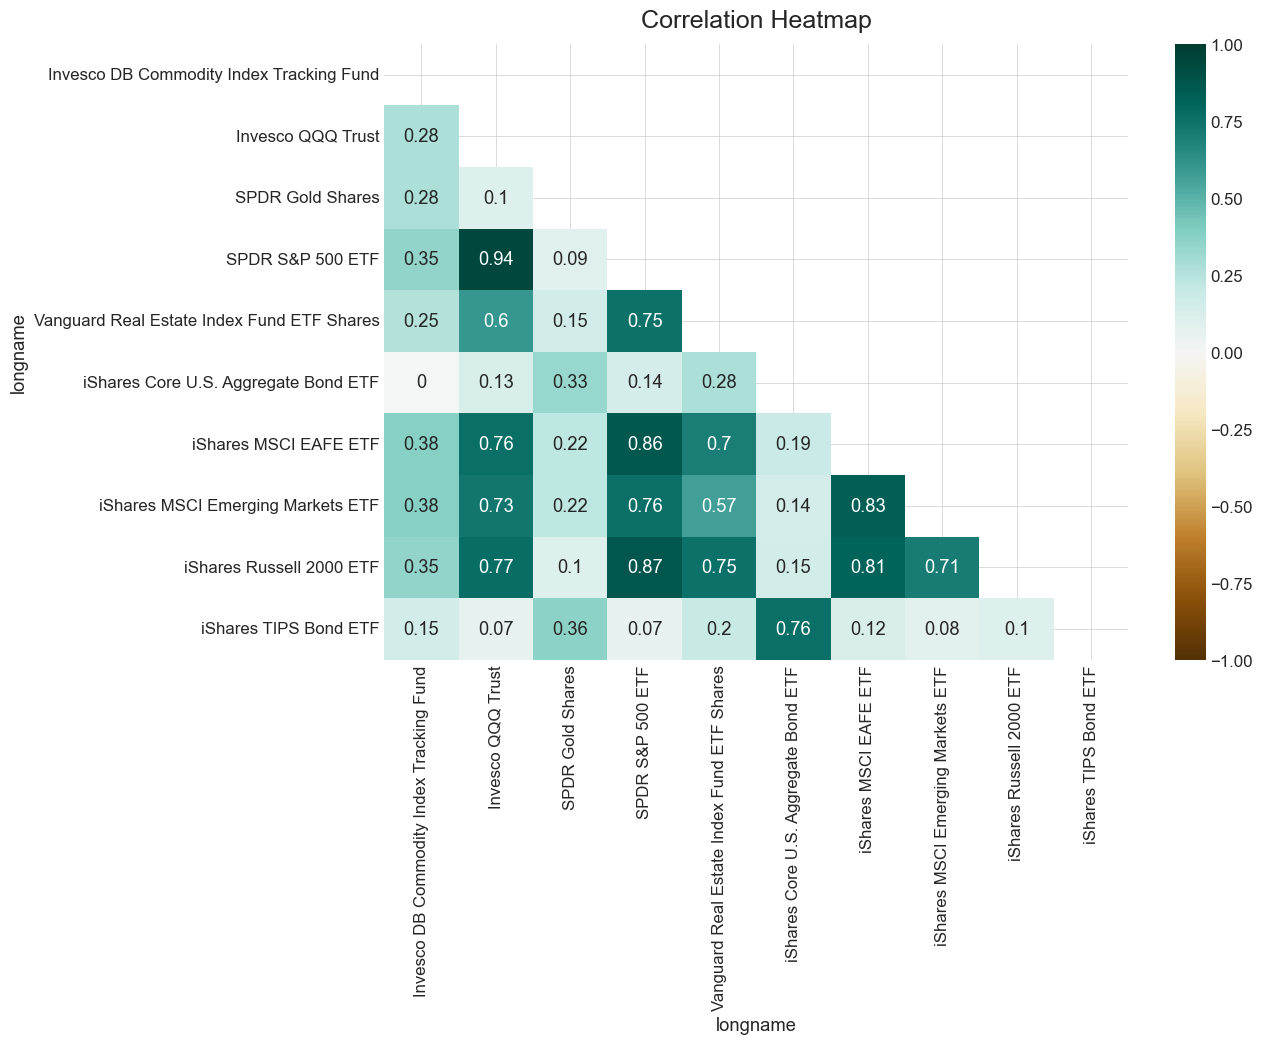

In [62]:
# Correlation Matrix
print("Generating correlation matrix...")
correlation_matrix(
    returns_daily,
    corr_limit=None,
    figsize=(12, 8),
    diagonal=True
)
plt.show()

Generating monthly heatmap...


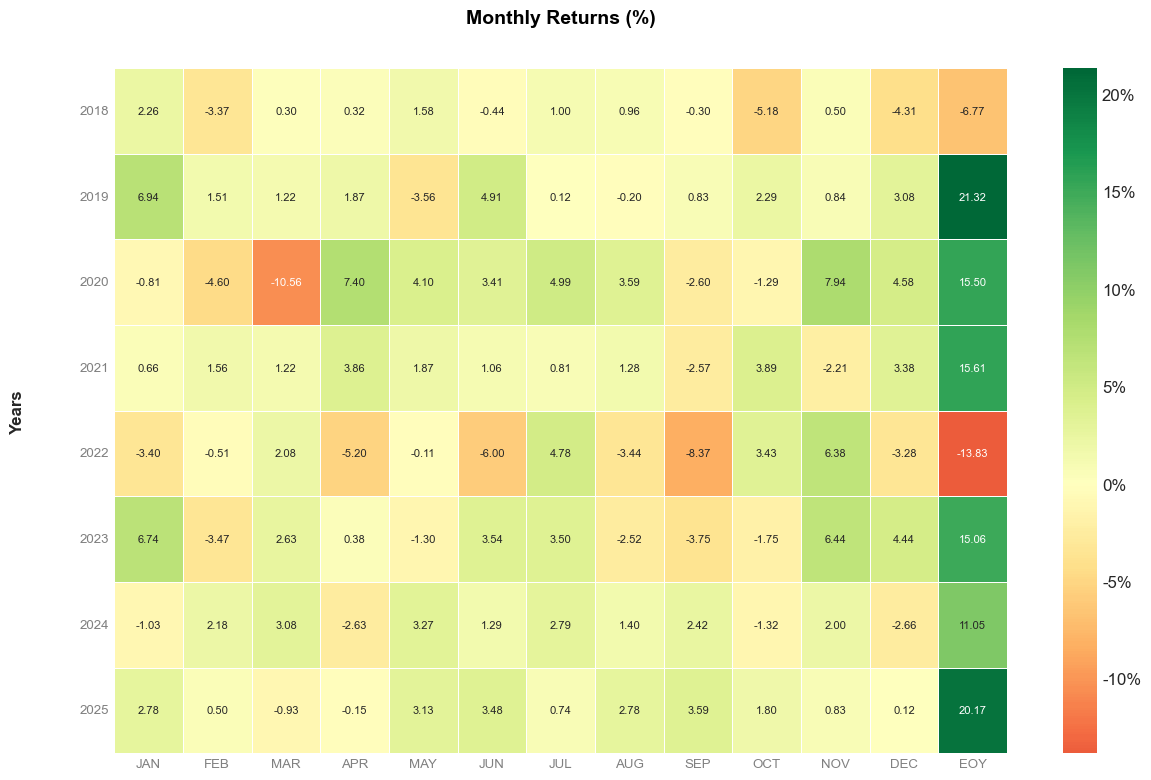

In [63]:
# Monthly Returns Heatmap
print("Generating monthly heatmap...")
fig = monthly_heatmap(
    returns=portfolio_returns,
    annot_size=8,
    figsize=(12, 8),
    cbar=True,
    eoy=True,
    show=True
)

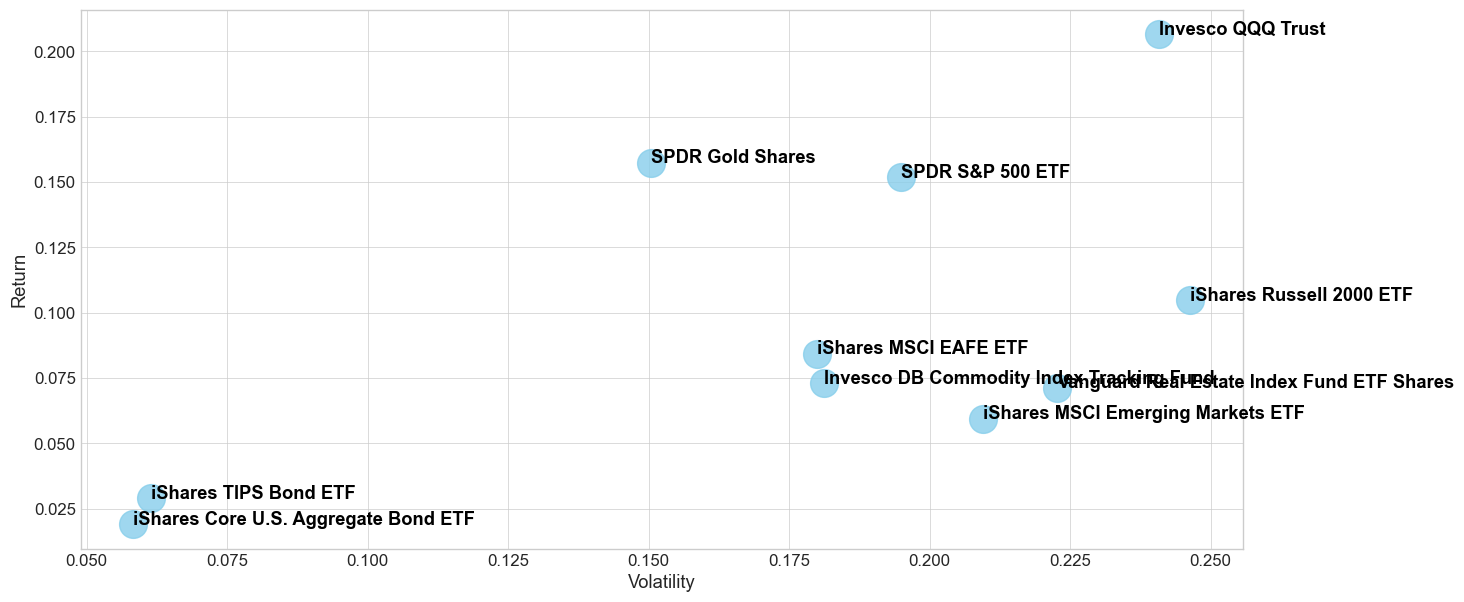

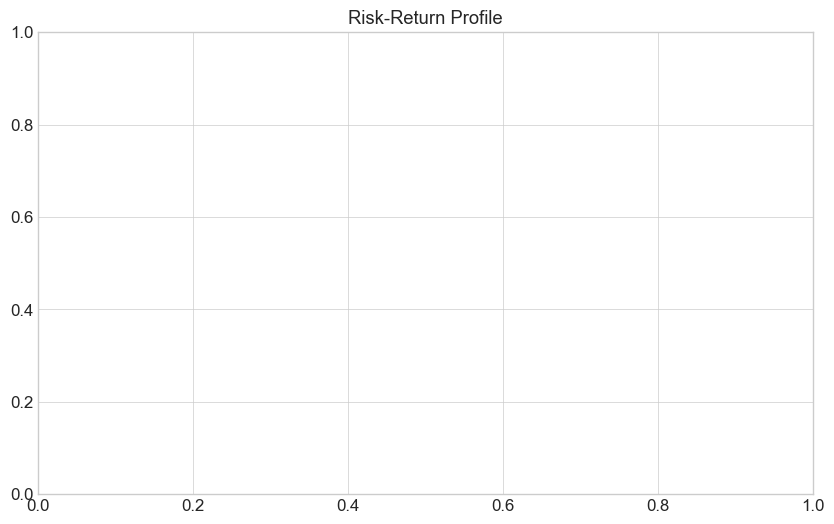

In [64]:
# Risk-Return Scatter Plot
risk_return = pd.DataFrame({
    'Return': returns_daily.mean() * 252,
    'Volatility': returns_daily.std() * np.sqrt(252)
})

scatter_plot_simple(risk_return, x='Volatility', y='Return')
plt.title('Risk-Return Profile')
plt.show()

## 12. Portfolio Selection <a id='portfolio-selection'></a>

Generate all possible portfolio combinations.

In [65]:
from myPortfolioManagement.myPortfolioSelection import (
    possible_combinations
)

assets = ['SPY', 'QQQ', 'IWM', 'AGG', 'GLD']

In [66]:
# All combinations of 2-4 assets
combinations = possible_combinations(
    assets_to_consider=assets,
    min_assets=2,
    max_assets=4
)

print(f"Number of possible portfolios (2-4 assets): {len(combinations)}")
print("\nFirst 10 combinations:")
for i, combo in enumerate(combinations[:10]):
    print(f"  {i+1}. {combo}")

possible_combinations took 0.000ms
Number of possible portfolios (2-4 assets): 25

First 10 combinations:
  1. ['SPY', 'QQQ']
  2. ['SPY', 'IWM']
  3. ['SPY', 'AGG']
  4. ['SPY', 'GLD']
  5. ['QQQ', 'IWM']
  6. ['QQQ', 'AGG']
  7. ['QQQ', 'GLD']
  8. ['IWM', 'AGG']
  9. ['IWM', 'GLD']
  10. ['AGG', 'GLD']


In [67]:
# Combinations with must-have assets
combinations_must_have = possible_combinations(
    assets_to_consider=assets,
    min_assets=3,
    max_assets=4,
    must_have=['SPY', 'AGG']
)

print(f"Portfolios that must include SPY and AGG: {len(combinations_must_have)}")
for combo in combinations_must_have:
    print(f"  {combo}")

possible_combinations took 0.000ms
Portfolios that must include SPY and AGG: 6
  ['SPY', 'QQQ', 'AGG']
  ['SPY', 'IWM', 'AGG']
  ['SPY', 'AGG', 'GLD']
  ['SPY', 'QQQ', 'IWM', 'AGG']
  ['SPY', 'QQQ', 'AGG', 'GLD']
  ['SPY', 'IWM', 'AGG', 'GLD']


## 13. Complete Workflow Example <a id='workflow'></a>

End-to-end portfolio management workflow.

In [68]:
print("="*80)
print("COMPLETE WORKFLOW - END TO END EXAMPLE")
print("="*80)

print("""
This section demonstrates a complete portfolio management workflow:
1. Fetch data
2. Calculate returns
3. Optimize portfolio
4. Backtest strategy
5. Analyze performance
""")

COMPLETE WORKFLOW - END TO END EXAMPLE

This section demonstrates a complete portfolio management workflow:
1. Fetch data
2. Calculate returns
3. Optimize portfolio
4. Backtest strategy
5. Analyze performance



In [69]:
# Step 1: Data already fetched above
print("Step 1: Using previously fetched data...")
print(f"  Assets: {list(prices.columns)}")
print(f"  Period: {prices.index[0]} to {prices.index[-1]}")

Step 1: Using previously fetched data...
  Assets: ['Invesco DB Commodity Index Tracking Fund', 'Invesco QQQ Trust', 'SPDR Gold Shares', 'SPDR S&P 500 ETF', 'Vanguard Real Estate Index Fund ETF Shares', 'iShares Core U.S. Aggregate Bond ETF', 'iShares MSCI EAFE ETF', 'iShares MSCI Emerging Markets ETF', 'iShares Russell 2000 ETF', 'iShares TIPS Bond ETF']
  Period: 2018-01-02 00:00:00 to 2025-12-19 00:00:00


In [70]:
# Step 2: Split into training and testing
split_date = '2023-01-01'
returns_train = returns_daily[returns_daily.index < split_date]
returns_test = returns_daily[returns_daily.index >= split_date]

print(f"\nStep 2: Train/Test Split at {split_date}")
print(f"  Training: {len(returns_train)} days")
print(f"  Testing: {len(returns_test)} days")


Step 2: Train/Test Split at 2023-01-01
  Training: 1258 days
  Testing: 745 days


In [71]:
# Step 3: Optimize portfolios on training data
print("\nStep 3: Optimizing portfolios on training data...")

weights_hrp_train = HRP(
    model='HRP',
    returns_training=returns_train.fillna(0),
    weight_max=0.25,
    weight_min=0.02
)
print("  HRP weights optimized")

weights_equal_train = equal_weight_portfolio(returns_train)
print("  Equal weight portfolio created")


Step 3: Optimizing portfolios on training data...
  HRP weights optimized
  Equal weight portfolio created


In [72]:
# Step 4: Calculate out-of-sample returns
print("\nStep 4: Calculating out-of-sample returns...")

# HRP portfolio returns
hrp_weights_dict = weights_hrp_train['port_weight'].to_dict()
portfolio_hrp_test = (returns_test * pd.Series(hrp_weights_dict)).sum(axis=1)
portfolio_hrp_test.name = 'HRP'

# Equal weight returns
equal_weights_dict = weights_equal_train['port_naive'].to_dict()
portfolio_equal_test = (returns_test * pd.Series(equal_weights_dict)).sum(axis=1)
portfolio_equal_test.name = 'Equal_Weight'

# Combine for comparison
portfolio_comparison = pd.DataFrame({
    'HRP': portfolio_hrp_test,
    'Equal_Weight': portfolio_equal_test,
    'SPY_Benchmark': returns_test.iloc[:, 0]
})

print("  Out-of-sample portfolios calculated")


Step 4: Calculating out-of-sample returns...
  Out-of-sample portfolios calculated


In [73]:
# Step 5: Performance analysis
print("\nStep 5: Out-of-Sample Performance Analysis...")

test_stats = get_main_stats(portfolio_comparison, rf=0.04)
print("\nOut-of-Sample Performance Metrics:")
print(test_stats.round(4))


Step 5: Out-of-Sample Performance Analysis...
get_main_stats took 123.10ms

Out-of-Sample Performance Metrics:
               total_ret   cagr  adjusted_sortino  sharpe  calmar  max_drawdown
HRP               0.5378 0.1565            2.1566  1.9886  2.4603       -0.0636
Equal_Weight      0.5355 0.1559            1.4924  1.4182  1.3803       -0.1130
SPY_Benchmark     0.0245 0.0082           -0.0589 -0.0605  0.0593       -0.1382


In [74]:
# Cumulative returns
cum_returns = (1 + portfolio_comparison).cumprod()
print("\nCumulative Returns (End of Period):")
print(cum_returns.iloc[-1].round(4))


Cumulative Returns (End of Period):
HRP             1.5378
Equal_Weight    1.5355
SPY_Benchmark   1.0245
Name: 2025-12-19 00:00:00, dtype: float64


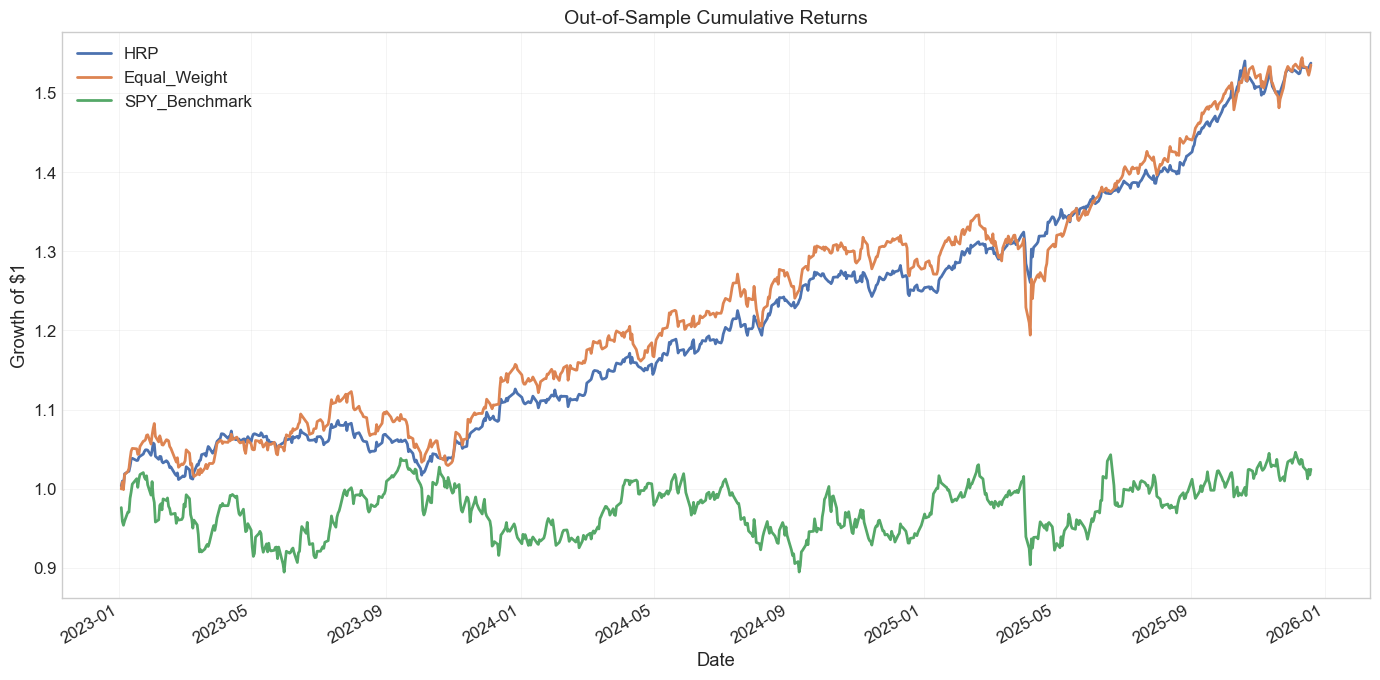

In [75]:
# Visualize cumulative returns
fig, ax = plt.subplots(figsize=(14, 7))
cum_returns.plot(ax=ax, linewidth=2)
ax.set_title('Out-of-Sample Cumulative Returns', fontsize=14)
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated the complete functionality of the myPortfolioManagement library:

### Key Findings
- Analyzed **{len(tickers)}** diverse assets
- Generated **7+** different portfolio strategies
- Tested multiple optimization methods (HRP, HERC, GMV, Max Sharpe, CVaR)
- Performed comprehensive backtesting and simulation

### Next Steps
1. Review portfolio weights and adjust constraints
2. Run more extensive backtests with different parameters
3. Implement rebalancing strategies
4. Add transaction costs and slippage
5. Consider regime-based allocation

### Resources
- Full documentation: See README.md
- Example scripts: examples_portfolio_management.py
- GitHub: [QuantitativePortfolioManagement](https://github.com/ferhat00/QuantitativePortfolioManagement)